In [1]:
import numpy as np
from numpy import pi, log, linspace
from utils import e_r_cpa_numerator, e_r_cpa_denominator, e_r_cpa, h_r_cpa_numerator, h_r_cpa, hl2, hl2prime
import matplotlib.pyplot as plt

### In this notebook, we recreate Figure 1 of the following paper: [Completeness and time-independent perturbation of morphology-dependent resonances in dielectric spheres](https://opg.optica.org/josab/fulltext.cfm?uri=josab-13-5-805)

In [4]:
n = 1.33; l = 10; # Index of refraction and Angular momentum, respectively
omega_imag_asymptotic = -1/(2*n)*log((n+1)/(n-1)) # Asymptotic value for the imaginary part of the normalized frequency 
N = 2000; M = 2000;
x_real = linspace(-1, 40, N); x_imag = linspace(-8, -0.1, M);
x = x_real.reshape((N, 1)).repeat(M, axis=1) + 1j*x_imag.reshape((1, M)).repeat(N, axis=0);
s_arr_tm = e_r_cpa(l, x, n**2) # Scattering coefficients for the TM channel
s_arr_te = h_r_cpa(l, x, n**2) # Scattering coefficients for the TE channel

### Uncomment the cell below to plot the rough locations of the resonances in the complex frequency plane (in a heatmap).

In [2]:
#fig, ax = plt.subplots(figsize=(10, 10))
#ax.contourf(log((np.abs(s_arr_tm)**2).T), origin="lower", cmap="hot", vmin=5);
#ax.contourf(log((np.abs(s_arr_te)**2).T), origin="lower", cmap="hot", vmin=2);

In [6]:
threshold = 6 # Threshold to find the resonances
tm_resonances = x[np.where(log((np.abs(s_arr_tm)**2)) > threshold)]
te_resonances = x[np.where(log((np.abs(s_arr_te)**2)) > threshold)];

### Uncomment the cell below to plot the rough locations of the resonances in the complex frequency plane (in a scatter plot).

In [7]:
#plt.scatter(tm_resonances.real, tm_resonances.imag)
#plt.scatter(te_resonances.real, te_resonances.imag, color="red");

In [8]:
filtered_tm_resonances_real = []; filtered_tm_resonances_imag = [] # Choose one location for each resonance (TM)
filtered_te_resonances_real = []; filtered_te_resonances_imag = [] # Choose one location for each resonance (TE)

filtered_tm_resonances_real.append(tm_resonances.real[0]); filtered_tm_resonances_imag.append(tm_resonances.imag[0])
filtered_te_resonances_real.append(te_resonances.real[0]); filtered_te_resonances_imag.append(te_resonances.imag[0])

for (r, i) in zip(tm_resonances.real[1:], tm_resonances.imag[1:]):
    filter_out = 0
    for (r_filtered, i_filtered) in zip(filtered_tm_resonances_real, filtered_tm_resonances_imag):
        if (r-r_filtered)**2+(i-i_filtered)**2 < 0.15**2: # Ignore if the point is too close to any of the resonances already picked
            filter_out += 1
            continue
    if filter_out > 0:
        continue
    filtered_tm_resonances_real.append(r)
    filtered_tm_resonances_imag.append(i)

for (r, i) in zip(te_resonances.real[1:], te_resonances.imag[1:]):
    filter_out = 0
    for (r_filtered, i_filtered) in zip(filtered_te_resonances_real, filtered_te_resonances_imag):
        if (r-r_filtered)**2+(i-i_filtered)**2 < 0.15**2:
            filter_out += 1
            continue
    if filter_out > 0:
        continue
    filtered_te_resonances_real.append(r)
    filtered_te_resonances_imag.append(i)

### Uncomment the cell below to view the filtered (unique) resonance positions in a scatter plot. 

In [9]:
#plt.scatter(filtered_tm_resonances_real, filtered_tm_resonances_imag, s=100, color="black")
#plt.scatter(filtered_te_resonances_real, filtered_te_resonances_imag, s=100, color="red")
#plt.hlines([omega_imag_asymptotic], -10, 50, color="green", linestyle="dotted")
#plt.xlim(0, 40)
#plt.ylim(-8, 0);

### Now we do a finer mesh centered around each resonance in order to find more accurate locations in the complex frequency plane. In the below, uncomment the matplotlib commands to see the resonance locations.

In [10]:
zoomed_tm_resonances_real = []; zoomed_tm_resonances_imag = [];
N_prime = 250; M_prime = 250
for (r, i) in zip(filtered_tm_resonances_real, filtered_tm_resonances_imag):
    x_real = linspace(r-0.5, r+0.5, N_prime)
    x_imag = linspace(i-0.1, i+0.1, M_prime)
    x = x_real.reshape((N_prime, 1)).repeat(M_prime, axis=1) + 1j*x_imag.reshape((1, M_prime)).repeat(N_prime, axis=0)
    s_arr_tm = e_r_cpa(l, x, n**2)
    #plt.imshow(log(np.abs(s_arr_tm)**2), cmap="hot")
    #plt.show()
    best_x = x.flatten()[(np.abs(s_arr_tm)**2).argmax()]
    #print(best_x - (r+1j*i))
    zoomed_tm_resonances_real.append(best_x.real)
    zoomed_tm_resonances_imag.append(best_x.imag)

In [11]:
zoomed_te_resonances_real = []; zoomed_te_resonances_imag = []
N_prime = 250; M_prime = 250
for (r, i) in zip(filtered_te_resonances_real, filtered_te_resonances_imag):
    x_real = linspace(r-0.5, r+0.5, N_prime)
    x_imag = linspace(i-0.1, i+0.1, M_prime)
    x = x_real.reshape((N_prime, 1)).repeat(M_prime, axis=1) + 1j*x_imag.reshape((1, M_prime)).repeat(N_prime, axis=0)
    s_arr_te = h_r_cpa(l, x, n**2)
    #plt.imshow(log(np.abs(s_arr_te)**2), cmap="hot")
    #plt.show()
    best_x = x.flatten()[(np.abs(s_arr_te)**2).argmax()]
    #print(best_x - (r+1j*i))
    zoomed_te_resonances_real.append(best_x.real)
    zoomed_te_resonances_imag.append(best_x.imag)

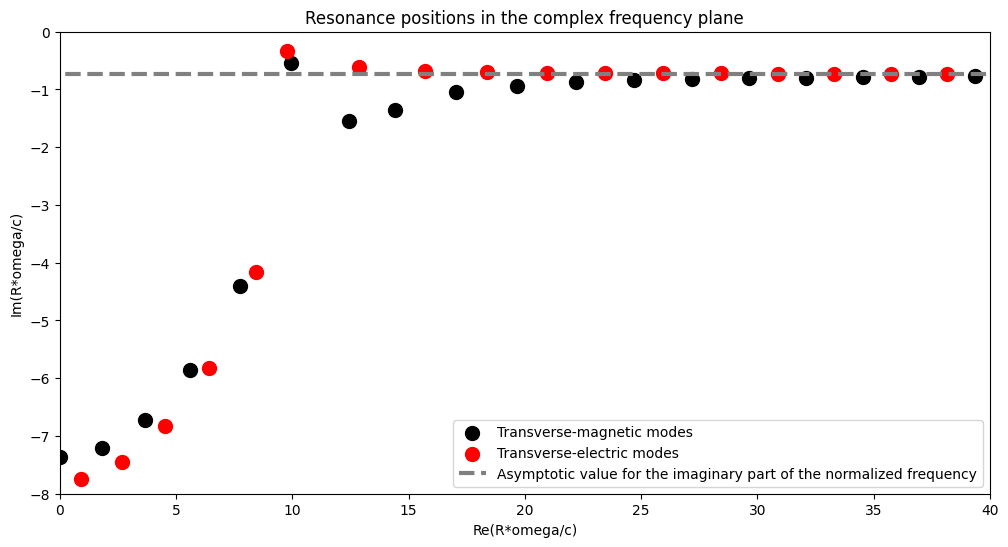

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(zoomed_tm_resonances_real, zoomed_tm_resonances_imag, color="black", s=100, label="Transverse-magnetic modes")
ax.scatter(zoomed_te_resonances_real, zoomed_te_resonances_imag, color="red", s=100, label="Transverse-electric modes");
ax.hlines([omega_imag_asymptotic], -10, 50, color="Gray", linestyle="dashed", linewidth=3, label="Asymptotic value for the imaginary part of the normalized frequency")
ax.set_xlim(0, 40); plt.ylim(-8, 0);
ax.legend();
ax.set_title("Resonance positions in the complex frequency plane");
ax.set_xlabel("Re(R*omega/c)")
ax.set_ylabel("Im(R*omega/c)");